<a href="https://colab.research.google.com/github/zhesun0304/ECON3916/blob/main/Assignment%203/Econ_3916_Assignment_3_Causal.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import sklearn as sk

In [3]:
# Phase 1, Step 1.1
# Zero-Inflated Gig Economy Tip Distribution

# Setting seed
np.random.seed(42)

# 100 zero tips
zeros = np.zeros(100)

# 150 right-skewed tips from Exponential(scale=5.0)
tips = np.random.exponential(scale=5.0, size=150)

# Foundational audit data
driver_tips = np.concatenate([zeros, tips])

# Optional sanity checks
print("Sample size:", driver_tips.size)
print("Number of zero tips:", np.sum(driver_tips == 0))
print("Number of positive tips:", np.sum(driver_tips > 0))
print("Mean tip:", driver_tips.mean())
print("Median tip:", np.median(driver_tips))
print("Std dev:", driver_tips.std(ddof=1))
print("Min tip:", driver_tips.min())
print("Max tip:", driver_tips.max())

Sample size: 250
Number of zero tips: 100
Number of positive tips: 150
Mean tip: 2.7690587934081927
Median tip: 0.7553316913699188
Std dev: 4.209476517960952
Min tip: 0.0
Max tip: 21.6707316979366


In [ ]:
# Base dataset from Step 1.1
np.random.seed(42)
zeros = np.zeros(100)
tips = np.random.exponential(scale=5.0, size=150)
driver_tips = np.concatenate([zeros, tips])

# Step 1.2: Manual Bootstrap Engine
B = 10000             # number of bootstrap resamples
n = driver_tips.size       # sample size
boot_medians = np.empty(B)    # store bootstrap medians

for b in range(B):
    # resample WITH replacement
    sample_idx = np.random.randint(0, n, size=n)
    bootstrap_sample = driver_tips[sample_idx]

    # statistic of interest: median
    boot_medians[b] = np.median(bootstrap_sample)

# 95% bootstrap percentile CI
ci_lower, ci_upper = np.percentile(boot_medians, [2.5, 97.5])

# Original sample stat
sample_median = np.median(driver_tips)

print("Original sample median:", sample_median)
print("Bootstrap 95% CI for median:", (ci_lower, ci_upper))

In [4]:
# Phase 2, Step 2.1
# Algorithmic Routing Crash

np.random.seed(42)

n_control = 500
n_treatment = 500

# Control: Normal(mean=35, sd=5)
control = np.random.normal(loc=35, scale=5, size=n_control)

# Treatment: Log-Normal(mean=3.4, sigma=0.4)
treatment = np.random.lognormal(mean=3.4, sigma=0.4, size=n_treatment)

# Observed simple difference in means
observed_diff = control.mean() - treatment.mean()

print("Control mean:", control.mean())
print("Treatment mean:", treatment.mean())
print("Observed difference in means (Control - Treatment):", observed_diff)

# Manual Permutation Test
all_deliveries = np.concatenate([control, treatment])

B = 5000
perm_diffs = np.empty(B)

for b in range(B):
    shuffled = np.random.permutation(all_deliveries)

    pseudo_control = shuffled[:n_control]
    pseudo_treatment = shuffled[n_control:]

    perm_diffs[b] = pseudo_control.mean() - pseudo_treatment.mean()

# Two-sided empirical p-value:
empirical_p_value = np.mean(np.abs(perm_diffs) >= abs(observed_diff))

print("Empirical two-sided p-value:", empirical_p_value)

Control mean: 35.03418997294323
Treatment mean: 32.76920784231749
Observed difference in means (Control - Treatment): 2.2649821306257394
Empirical two-sided p-value: 0.0004


In [5]:
# Phase 3, Step 3.1
df = pd.read_csv("swiftcart_loyalty.csv")

group_means = df.groupby("subscriber")["post_spend"].mean()

naive_sdo = group_means[1] - group_means[0]

print("Mean post_spend for D=0:", group_means[0])
print("Mean post_spend for D=1:", group_means[1])
print("Naive Simple Difference in Means (D=1 - D=0):", naive_sdo)

Mean post_spend for D=0: 56.47291665600162
Mean post_spend for D=1: 74.04358604052543
Naive Simple Difference in Means (D=1 - D=0): 17.570669384523804


In [6]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import NearestNeighbors

# Treatment
D = df["subscriber"]

# Pre-treatment covariates only
X = df[["pre_spend", "account_age", "support_tickets"]]
Y = df["post_spend"]

# Propensity Score Model
logit = LogisticRegression(max_iter=1000)
logit.fit(X, D)

# Estimated propensity scores: P(D=1|X)
df["propensity_score"] = logit.predict_proba(X)[:, 1]

# 1-to-1 Nearest Neighbor Matching
treated = df[df["subscriber"] == 1].copy()
control = df[df["subscriber"] == 0].copy()

# Match each treated user to the single closest control user
nn = NearestNeighbors(n_neighbors=1)
nn.fit(control[["propensity_score"]])

distances, indices = nn.kneighbors(treated[["propensity_score"]])

matched_control = control.iloc[indices.flatten()].copy()

# ATT calculation
att = np.mean(
    treated["post_spend"].to_numpy() - matched_control["post_spend"].to_numpy()
)

# Naive SDO for comparison
naive_sdo = (
    df.loc[df["subscriber"] == 1, "post_spend"].mean()
    - df.loc[df["subscriber"] == 0, "post_spend"].mean()
)

print("Naive SDO:", naive_sdo)
print("ATT from PSM:", att)

Naive SDO: 17.57066938452379
ATT from PSM: 9.913855182824864


Naive SDO: 17.57066938452379
PSM ATT: 9.913855182824864
df_unmatched shape: (8941, 6)
df_matched shape: (8400, 6)


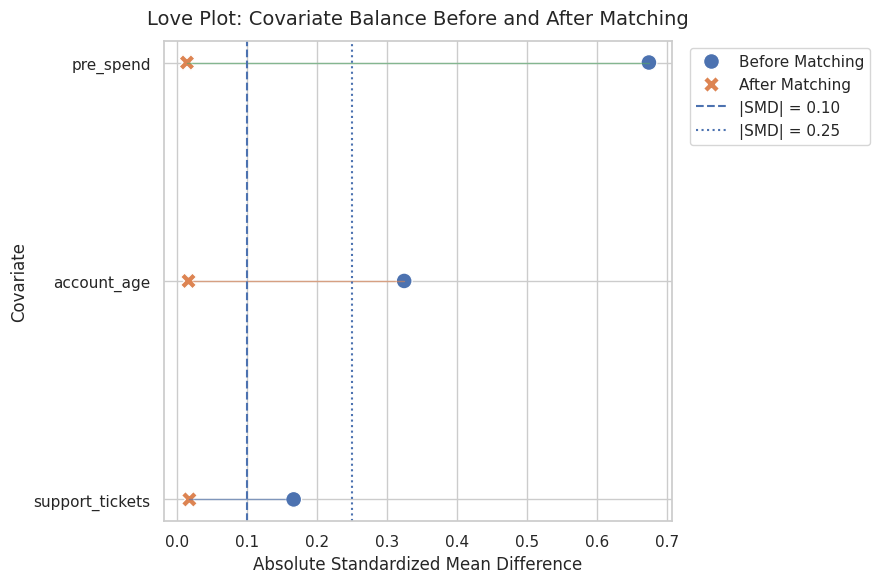

Standardized Mean Differences Before and After Matching:
      Covariate  Before Matching  After Matching
      pre_spend         0.673959        0.013664
    account_age         0.324109       -0.015871
support_tickets        -0.166146        0.017112


In [8]:
# Phase 4: AI Expansion (The Co-Pilot Era)
# =========================================================
# LOVE PLOT FOR COVARIATE BALANCE BEFORE / AFTER MATCHING
# Assumes:
#   - df_unmatched: original sample
#   - df_matched: matched sample
#   - treatment column is named 'subscriber'
#   - all other listed columns are pre-treatment covariates
# =========================================================

# --------------------------------------------------
# Load data
# --------------------------------------------------
df = pd.read_csv("swiftcart_loyalty.csv").copy()

# Variable names
treatment_col = "subscriber"
outcome_col = "post_spend"
covariates = ["pre_spend", "account_age", "support_tickets"]

# --------------------------------------------------
# Define the unmatched dataset
# This is simply the original observational sample
# --------------------------------------------------
df_unmatched = df.copy()

# --------------------------------------------------
# Estimate propensity scores using pre-treatment covariates
# --------------------------------------------------
X = df_unmatched[covariates]
D = df_unmatched[treatment_col]

logit = LogisticRegression(max_iter=1000)
logit.fit(X, D)

df_unmatched["propensity_score"] = logit.predict_proba(X)[:, 1]

# --------------------------------------------------
# Split treated and control groups
# --------------------------------------------------
treated = df_unmatched[df_unmatched[treatment_col] == 1].copy().reset_index(drop=True)
control = df_unmatched[df_unmatched[treatment_col] == 0].copy().reset_index(drop=True)

# --------------------------------------------------
# 1:1 nearest-neighbor matching on propensity score
# Each treated unit gets the single closest control unit
# --------------------------------------------------
nn = NearestNeighbors(n_neighbors=1)
nn.fit(control[["propensity_score"]])

distances, indices = nn.kneighbors(treated[["propensity_score"]])

matched_control = control.iloc[indices.flatten()].copy().reset_index(drop=True)
matched_treated = treated.copy().reset_index(drop=True)

# --------------------------------------------------
# Define the matched dataset
# This contains only treated units and their matched controls
# --------------------------------------------------
df_matched = pd.concat([matched_treated, matched_control], axis=0).reset_index(drop=True)

# --------------------------------------------------
# Optional: ATT calculation
# --------------------------------------------------
att = np.mean(
    matched_treated[outcome_col].to_numpy() - matched_control[outcome_col].to_numpy()
)

naive_sdo = (
    df_unmatched.loc[df_unmatched[treatment_col] == 1, outcome_col].mean()
    - df_unmatched.loc[df_unmatched[treatment_col] == 0, outcome_col].mean()
)

print("Naive SDO:", naive_sdo)
print("PSM ATT:", att)
print("df_unmatched shape:", df_unmatched.shape)
print("df_matched shape:", df_matched.shape)

# -----------------------------
# Standardized Mean Difference
# -----------------------------
def standardized_mean_difference(df_in, treat_col, covariate):
    treated_vals = df_in[df_in[treat_col] == 1][covariate].dropna().to_numpy()
    control_vals = df_in[df_in[treat_col] == 0][covariate].dropna().to_numpy()

    mean_t = treated_vals.mean()
    mean_c = control_vals.mean()

    var_t = treated_vals.var(ddof=1)
    var_c = control_vals.var(ddof=1)

    pooled_sd = np.sqrt((var_t + var_c) / 2)

    if pooled_sd == 0:
        return 0.0

    return (mean_t - mean_c) / pooled_sd


# -----------------------------
# Compute SMDs before and after matching
# -----------------------------
balance_rows = []

for cov in covariates:
    smd_before = standardized_mean_difference(df_unmatched, treatment_col, cov)
    smd_after = standardized_mean_difference(df_matched, treatment_col, cov)

    balance_rows.append({
        "Covariate": cov,
        "Before Matching": smd_before,
        "After Matching": smd_after
    })

balance_df = pd.DataFrame(balance_rows)

# Convert to long format for plotting
plot_df = balance_df.melt(
    id_vars="Covariate",
    value_vars=["Before Matching", "After Matching"],
    var_name="Sample",
    value_name="SMD"
)

# Love plots usually use absolute SMD
plot_df["Abs_SMD"] = plot_df["SMD"].abs()

# Order variables by pre-match imbalance
cov_order = (
    balance_df.assign(abs_before=balance_df["Before Matching"].abs())
    .sort_values("abs_before", ascending=True)["Covariate"]
    .tolist()
)

# -----------------------------
# Plot
# -----------------------------
sns.set_theme(style="whitegrid")
fig, ax = plt.subplots(figsize=(9, 6))

sns.scatterplot(
    data=plot_df,
    x="Abs_SMD",
    y="Covariate",
    hue="Sample",
    style="Sample",
    s=130,
    ax=ax
)

# Draw line segments linking before/after for each covariate
for cov in cov_order:
    before_val = plot_df[
        (plot_df["Covariate"] == cov) &
        (plot_df["Sample"] == "Before Matching")
    ]["Abs_SMD"].values[0]

    after_val = plot_df[
        (plot_df["Covariate"] == cov) &
        (plot_df["Sample"] == "After Matching")
    ]["Abs_SMD"].values[0]

    ax.plot([before_val, after_val], [cov, cov], alpha=0.6, linewidth=1)

# Conventional balance thresholds
ax.axvline(0.10, linestyle="--", linewidth=1.5, label="|SMD| = 0.10")
ax.axvline(0.25, linestyle=":", linewidth=1.5, label="|SMD| = 0.25")

ax.set_title("Love Plot: Covariate Balance Before and After Matching", fontsize=14, pad=12)
ax.set_xlabel("Absolute Standardized Mean Difference", fontsize=12)
ax.set_ylabel("Covariate", fontsize=12)

# Clean duplicated legend entries
handles, labels = ax.get_legend_handles_labels()
seen = set()
clean_handles = []
clean_labels = []

for h, l in zip(handles, labels):
    if l not in seen:
        clean_handles.append(h)
        clean_labels.append(l)
        seen.add(l)

ax.legend(clean_handles, clean_labels, bbox_to_anchor=(1.02, 1), loc="upper left")

plt.tight_layout()
plt.show()

# -----------------------------
# Optional printed diagnostics
# -----------------------------
print("Standardized Mean Differences Before and After Matching:")
print(balance_df.to_string(index=False))